In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Red Wine Quality dataset from the UCI Machine Learning Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Dataset loaded with 1599 rows and 12 columns.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


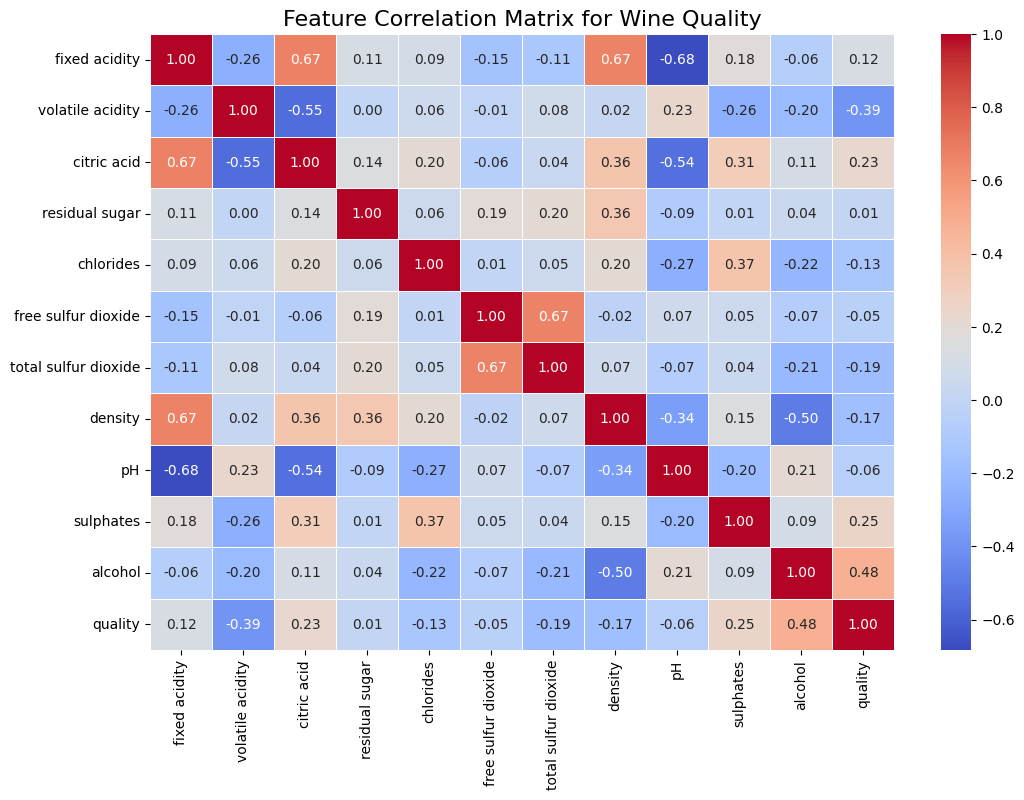


Correlation with Quality Score:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [2]:
# Compute the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Render the matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix for Wine Quality', fontsize=16)
plt.show()

# Isolate and print the correlations specifically linked to the 'quality' target
print("\nCorrelation with Quality Score:")
print(correlation_matrix['quality'].sort_values(ascending=False))

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert quality scores to binary: 7 or higher is 'Good' (1), else 'Standard' (0)
df['good_wine'] = [1 if x >= 7 else 0 for x in df['quality']]

# Separate our features (X) from our target variable (y)
X = df.drop(['quality', 'good_wine'], axis=1)
y = df['good_wine']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the feature scales (crucial for accurate gradient descent if we used other models,
# but also good practice here)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (1279, 11)
Testing data shape: (320, 11)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the unseen test data
y_pred = rf_model.predict(X_test_scaled)

# Print the performance metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       273
           1       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



/tmp/ipykernel_1324/1698109742.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


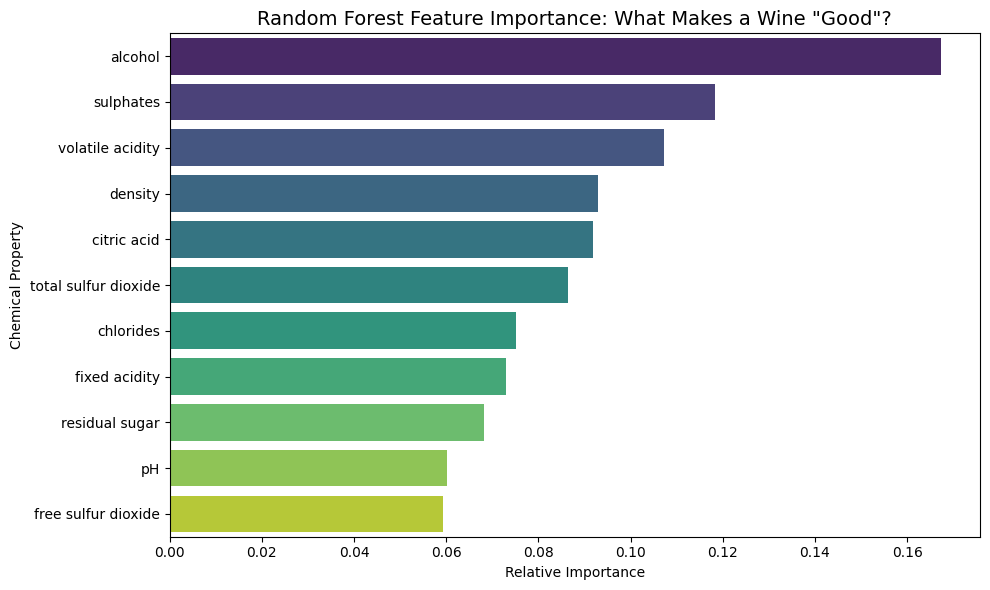

In [5]:
import numpy as np

# Extract feature importances from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort the features by their importance
indices = np.argsort(importances)[::-1]

# Render the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title('Random Forest Feature Importance: What Makes a Wine "Good"?', fontsize=14)
plt.xlabel('Relative Importance')
plt.ylabel('Chemical Property')
plt.tight_layout()
plt.show()

## Resources

### Red Wine Quality Prediction Project

**Project Overview**

This project focuses on predicting the quality of red wines based on their physiochemical properties. The goal is to classify wines as 'Good' (quality score of 7 or higher) or 'Standard' (quality score below 7) using machine learning techniques. We explore the dataset, preprocess features, train a classification model, and evaluate its performance, ultimately identifying key features influencing wine quality.

**Data Source**

The dataset used is the Red Wine Quality dataset, sourced from the UCI Machine Learning Repository.

**Key Steps Performed:**

*   **Data Loading and Initial Inspection**: The Red Wine Quality dataset was loaded from a CSV file into a pandas DataFrame, and its initial structure was displayed.
*   **Exploratory Data Analysis (EDA)**: A correlation matrix and heatmap were generated to visualize the relationships between features. The correlation of each feature with the 'quality' target variable was specifically analyzed and printed.
*   **Data Preprocessing**: The original 'quality' scores were converted into a binary target variable ('good_wine'). The dataset was then split into training and testing sets, and features were standardized using `StandardScaler` to prepare them for model training.
*   **Model Training & Evaluation (Random Forest Classifier)**: A Random Forest Classifier was initialized and trained on the scaled training data. The model's performance was evaluated using a classification report on the unseen test data.
*   **Feature Importance Analysis**: The importance of each chemical property in determining wine quality was extracted from the trained Random Forest model and visualized using a bar chart, highlighting the most influential features.

This notebook demonstrates an end-to-end machine learning workflow for a classification task, from data loading and preparation to model training, evaluation, and interpretability.